# Phenomenon 3: Emotional Suppression Under Observation

## Question guiding exploration

Is there evidence that participants modulate their facial expressions because they know they are being recorded? How often does each participant show their internal emotions physically though their facial expressions? What are the facial expressions of the participants when enjoying the activities? Does this vary per task?

## Methodology

The analysis is centered on ResMaskNet because that is the model used in the investigation. ResMaskNet assigns a probability in the range [0, 1] to each of seven emotions per frame: anger, disgust, fear, happiness, sadness, surprise, and neutral. 

Before the analysis, tasks or sections with no self-report (tasks 1.1, 2.2, 3.2, 4.2, 5.5, 6.2, 7.5, 8.2, and 9.1) were removed from the data. The rows where the reported valence was zero, indicating a missing response, were deleted, as well as the rows where no face was detected.

**Section 1: Correlation of Happiness / sadness vs. reported valence**
Two correlation analyses were performed in this section. First, Pearson r is computed across all tasks pooled together, then separately for each task. A scatter plot with a regression line is produced for each emotion for the pooled analysis.

Each subject-task pair was reduced to a single value by computing the mean of the top 10% highest happiness and sadness scores recorded during the task. This approach was chosen because, if you are doing something that you enjoy, more than likely you will not be smiling 100% of the time. Instead, you have a neutral face most of the time and every once in a while something happens that makes you particularly happy or sad. Averaging only the top values captures the actual emotional moments while filtering out the neutral baseline noise. Self-reported valence was taken as the single value provided by the participant at the end of the task.

**Section 2: Correlation of neutral expression vs. reported valence**
Similarly to the previous section one correlation analysis was made by pooling the data, while the other was done by separating each task. Here, the correlation was made between the percentage of time a person had a neutral expression with respect to the reported valence. To calculate the time a person had a neutral expression, we classify a frame as neutral when the neutral expression exceeds every other emotion probability. Again, self-reported valence was taken as the single value provided by the participant at the end of the task.

**Dead-ends (Section 3)**
The naïve per-task *mean* happiness / sadness was also tested. Because most frames hover near 0, the mean is dominated by the neutral baseline and yields weaker, less interpretable correlations. This approach was ultimately discarded.

## Additional considerations
No random seed was needed, so none is provided.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import math
from IPython.display import display, Markdown
from scipy.stats import pearsonr

# Ensure output directory exists
os.makedirs('../outputs/figures/', exist_ok=True)

# Plotting aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load dataset
df = pd.read_csv('../NPFC-Test_Database_V2.csv')

# Ensure Task_Num is treated as string to match the PDF notation (e.g., '3.1', '6.1')
df['Task_Num'] = df['Task_Num'].astype(str)

# Delete all self-report tasks or sections with no self report
excluded_tasks = ['1.1', '2.2', '3.2', '4.2', '5.5', '6.2', '7.5', '8.2', '9.1']
df = df[~df['Task_Num'].isin(excluded_tasks)]

# Delete valence data points that are 0 (indicating no self report)
df = df[df['Selfreport_valence'] != 0]

# 1. Correlation between facial expression vs. perceived valence

We will calculate the correlation between happy and sad facial expression with the perceived valence the people reported, with the methodology previously explained.

## 1.1 General correlation

This is the correlation without making explicit separation per task.


### Correlation Results
| Metric | Correlation ($r$) | $p$-value |
| :--- | :--- | :--- |
| **Happiness** | -0.100 | 0.0247 |
| **Sadness** | -0.151 | 0.0007 |


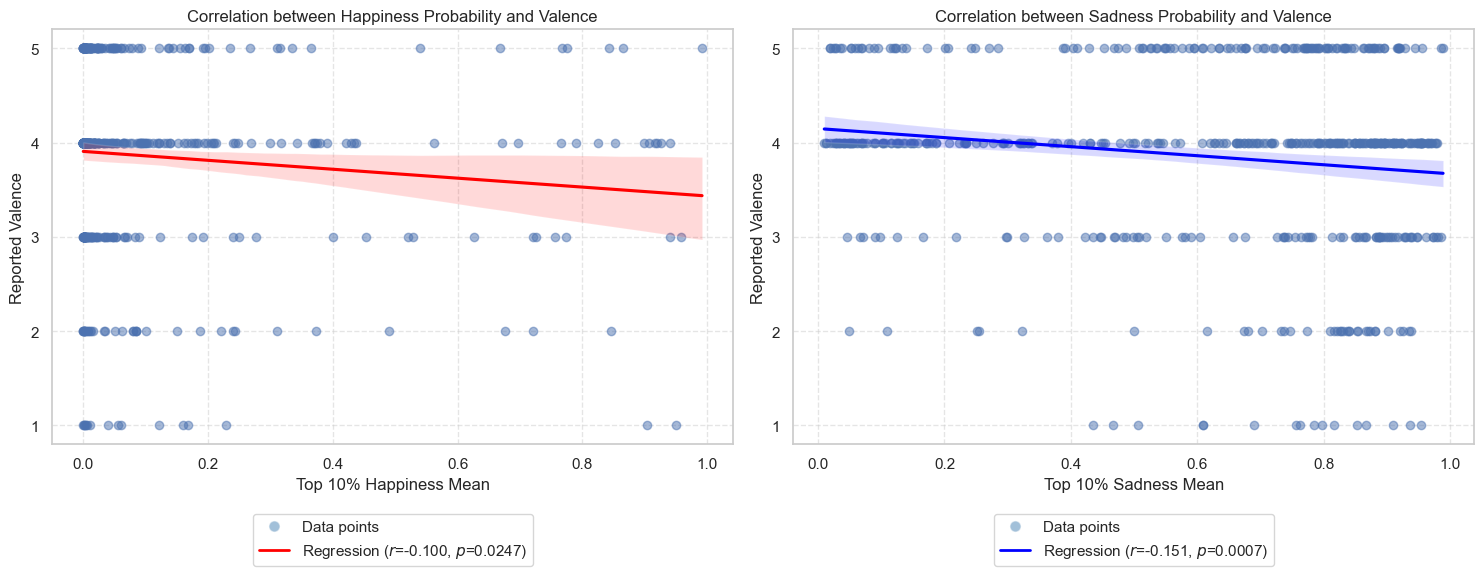

In [2]:
k_largest_df = df.groupby(['Subject_ID', 'Task_Num']).agg(
  agg_happiness=('resmasknet_happiness', lambda x: x.nlargest(int(len(x) * 0.1)).mean()), 
  agg_sadness=('resmasknet_sadness', lambda x: x.nlargest(int(len(x) * 0.1)).mean()), 
  reported_valence=('Selfreport_valence', 'max'), # Same for all
  reported_arousal=('Selfreport_arousal', 'max')
).reset_index()

k_largest_df = k_largest_df.dropna(subset=['reported_valence', 'agg_happiness', 'agg_sadness'])

corr_h, p_h = pearsonr(k_largest_df['reported_valence'], k_largest_df['agg_happiness'])
corr_s, p_s = pearsonr(k_largest_df['reported_valence'], k_largest_df['agg_sadness'])

display(Markdown(f"""
### Correlation Results
| Metric | Correlation ($r$) | $p$-value |
| :--- | :--- | :--- |
| **Happiness** | {corr_h:.3f} | {p_h:.4f} |
| **Sadness** | {corr_s:.3f} | {p_s:.4f} |
"""))

# Create a 1x2 grid (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Happiness vs Reported Valence
sns.regplot(
    ax=axes[0], 
    data=k_largest_df, 
    x='agg_happiness', 
    y='reported_valence', 
    scatter_kws={'alpha':0.5}, 
    line_kws={'color':'red'}
)
axes[0].set_title('Correlation between Happiness Probability and Valence')
axes[0].set_xlabel('Top 10% Happiness Mean')
axes[0].set_ylabel('Reported Valence')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].set_yticks([1, 2, 3, 4, 5])
axes[0].legend(
    handles=[
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue',
                   alpha=0.5, markersize=8, label='Data points'),
        plt.Line2D([0], [0], color='red', linewidth=2,
                   label=f'Regression ($r$={corr_h:.3f}, $p$={p_h:.4f})')
    ],
    loc='upper center', 
    bbox_to_anchor=(0.5, -0.15), 
    ncol=1
)

# Plot 2: Sadness vs Reported Valence
sns.regplot(
    ax=axes[1], 
    data=k_largest_df, 
    x='agg_sadness', 
    y='reported_valence', 
    scatter_kws={'alpha':0.5}, 
    line_kws={'color':'blue'}
)
axes[1].set_title('Correlation between Sadness Probability and Valence')
axes[1].set_xlabel('Top 10% Sadness Mean')
axes[1].set_ylabel('Reported Valence')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].set_yticks([1, 2, 3, 4, 5])
axes[1].legend(
    handles=[
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue',
                   alpha=0.5, markersize=8, label='Data points'),
        plt.Line2D([0], [0], color='blue', linewidth=2,
                   label=f'Regression ($r$={corr_s:.3f}, $p$={p_s:.4f})')
    ],
    loc='upper center', 
    bbox_to_anchor=(0.5, -0.15), 
    ncol=1
)

# Adjust layout to prevent label overlap
plt.tight_layout()
plt.savefig('../outputs/figures/phenomenon_3_fig1_general_correlation_happiness_sadness.png', dpi=150, bbox_inches='tight')
plt.show()

Both correlations were statistically significant. Contrary to intuitive expectations, happiness correlation was negative and not positive. This does not necessarily mean that the correlation is flawed, there can be possible explanations for this data behavior. One possibility is how the valence was obtained from the participants: they were asked "How much did you enjoy the task?". Therefore, in tasks such as the concentration video, one may really enjoy watching the video, but that may not translate to a "happy face" detected by the facial recognition model. Thus, this counterintuitive correlation supports the idea that enjoying the tasks may not directly cause a "happy face".

## 1.2 Per task correlation

This is the correlation analysis with task separation to possibly account for the different task types.

In [3]:
agg_types = ['agg_happiness', 'agg_sadness']

for agg in agg_types:
    results = []

    for task, group in k_largest_df.groupby('Task_Num'):
        # Ensure we have enough data points and no constant values (which break correlation)
        if len(group) > 1 and group['reported_valence'].nunique() > 1:
            r, p = pearsonr(group['reported_valence'], group[agg])
            results.append({
                'Task': task,
                'Correlation (r)': round(r, 3),
                'p-value': round(p, 4),
                'N': len(group),
                'Significant': 'Yes' if p < 0.05 else 'No'
            })

    task_corr_df = pd.DataFrame(results)
    title = f"Correlation Analysis per Task: {agg.replace('agg_', '').capitalize()} vs. Reported Valence"
    display(task_corr_df.style.set_caption(title))

,Task,Correlation (r),p-value,N,Significant
0,2.1,-0.014000,0.933800,38,No
1,3.1,-0.395000,0.012800,39,Yes
2,4.1,-0.058000,0.720400,40,No
3,5.1,-0.111000,0.494200,40,No
4,5.2,-0.097000,0.553400,40,No
5,5.3,-0.174000,0.283800,40,No
6,5.4,-0.130000,0.423600,40,No
7,6.1,-0.344000,0.032200,39,Yes
8,7.1,-0.179000,0.392700,25,No
9,7.2,-0.056000,0.729200,40,No


,Task,Correlation (r),p-value,N,Significant
0,2.1,-0.452000,0.004400,38,Yes
1,3.1,-0.052000,0.754500,39,No
2,4.1,-0.183000,0.258200,40,No
3,5.1,-0.097000,0.553600,40,No
4,5.2,-0.154000,0.342100,40,No
5,5.3,-0.076000,0.639900,40,No
6,5.4,-0.069000,0.674200,40,No
7,6.1,0.017000,0.919800,39,No
8,7.1,0.068000,0.746100,25,No
9,7.2,-0.154000,0.343700,40,No


The only correlations with p-value < 0.05 were Sadness in task 2.1, and Happiness in tasks 3.1 and 6.1.

This is quite interesting, even though the correlation was quite strong considering all tasks, when doing separate analysis there is no correlation. A possible explanation for this is the small N value for each of the tasks. This makes the correlation more vulnerable to outliers, which may increase the p value. Considering the origin of the data (the ResMaskNet facial recognition model), it is expected for the data to be a little prone to outliers (e.g. the model recognizing a happy face for just one row in the dataset, but then returning to neutral).

# 2. Correlation between valence and neutral facial expressions
Here, we consider the "prediction" of the model to be the facial expresion emotion with more probability. 



### Correlation Results
| Correlation ($r$) | $p$-value |
|  :--- | :--- |
|  0.097 | 0.0255 |


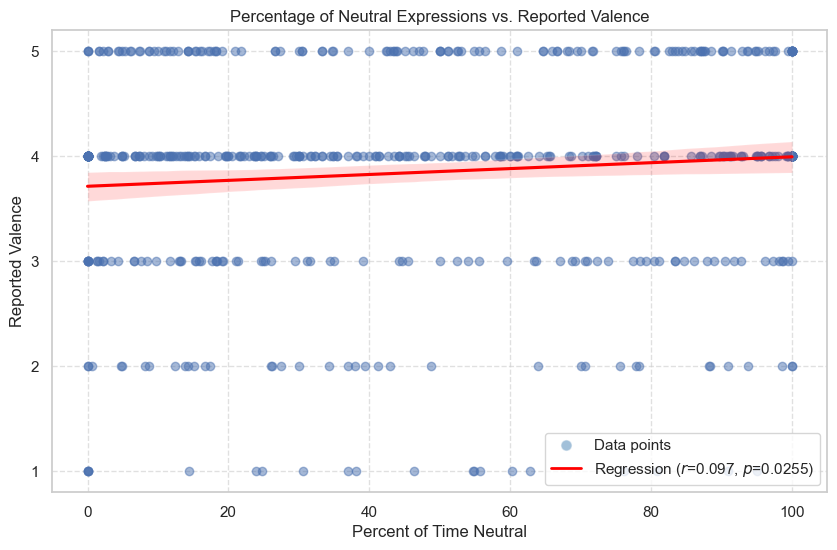

In [4]:
neutrality_df = df.copy()

other_emotion_cols = [
    'resmasknet_anger', 'resmasknet_disgust', 'resmasknet_fear', 
    'resmasknet_happiness', 'resmasknet_sadness', 'resmasknet_surprise'
]

# Calculate if neutral is the maximum emotion for each row. 
# This means the model 'predicts' a neutral expression more strongly than any other emotion.
neutrality_df['was_neutral'] = neutrality_df['resmasknet_neutral'] > df[other_emotion_cols].max(axis=1)

# Use mean to consider the % of the time 
neutrality_df = neutrality_df.groupby(['Subject_ID', 'Task_Num']).agg(
    neutral_pct=('was_neutral', 'mean'), 
    reported_valence=('Selfreport_valence', 'max'), 
).reset_index()

neutrality_df['neutral_pct'] = neutrality_df['neutral_pct'] * 100

# Correlation
corr_n, p_n = pearsonr(neutrality_df['reported_valence'], neutrality_df['neutral_pct'])
display(Markdown(f"""
### Correlation Results
| Correlation ($r$) | $p$-value |
|  :--- | :--- |
|  {corr_n:.3f} | {p_n:.4f} |
"""))

# Plot
plt.figure(figsize=(10, 6))
sns.regplot(data=neutrality_df, x='neutral_pct', y='reported_valence', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.title('Percentage of Neutral Expressions vs. Reported Valence')
plt.xlabel('Percent of Time Neutral')
plt.ylabel('Reported Valence')
plt.grid(True, linestyle='--', alpha=0.6)
plt.yticks([1, 2, 3, 4, 5])
plt.legend(
    handles=[
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue',
                   alpha=0.5, markersize=8, label='Data points'),
        plt.Line2D([0], [0], color='red', linewidth=2,
                   label=f'Regression ($r$={corr_n:.3f}, $p$={p_n:.4f})')
    ]
)
plt.savefig('../outputs/figures/phenomenon_3_fig2_neutral_pct_vs_valence.png', dpi=150, bbox_inches='tight')
plt.show()

There is a significant positive correlation (p < 0.5). In this case, more enjoyment in the activity seems to increase the percent of time the participants stayed with a neutral expression.

In [5]:
results = []
for task, group in neutrality_df.groupby('Task_Num'):
    # Ensure we have enough data points and no constant values (which break correlation)
    if len(group) > 1 and group['reported_valence'].nunique() > 1:
        
        r, p = pearsonr(group['reported_valence'], group['neutral_pct'])
        results.append({
            'Task': task,
            'Correlation (r)': round(r, 3),
            'p-value': round(p, 4),
            'Number of samples': len(group),
            'Significant': 'Yes' if p < 0.05 else 'No',
            "Percent of time with neutral expression": round(group['neutral_pct'].mean(), 2)
        })

task_corr_df = pd.DataFrame(results)
title = 'Correlation Analysis per Task: Neutral time vs. Reported Valence'
display(task_corr_df.style.set_caption(title))

,Task,Correlation (r),p-value,Number of samples,Significant,Percent of time with neutral expression
0,2.1,0.221000,0.175400,39,No,54.970000
1,3.1,0.377000,0.016400,40,Yes,40.670000
2,4.1,-0.022000,0.891800,41,No,57.810000
3,5.1,0.174000,0.277600,41,No,49.320000
4,5.2,0.303000,0.053700,41,No,47.340000
5,5.3,0.230000,0.148900,41,No,48.010000
6,5.4,0.305000,0.052500,41,No,44.390000
7,6.1,-0.209000,0.196400,40,No,49.240000
8,7.1,-0.014000,0.928400,41,No,53.570000
9,7.2,0.134000,0.401800,41,No,43.580000


Similarly to previous analysis, correlations were not very significant when analyzed task by task. The only exception being task 3.1, which is the math task. More enjoyment seems to correlate with a more "neutral" face. This could be related to how you react when you are concentrated during the math activities. Nonetheless, this was one of the activities with lower percentage of time with a neutral expression.

# Dead ends and failed approaches
Here are the approaches that were attempted, but failed or did not reach any relevant conclusions.

## Mean of ResMaskNet predictions as a measure of emotion during task
ResMaskNet uses a probability from 0 to 1 per emotion to indicate how likely are they to be showing this emotion. One may be tempted to use the average of happiness probability to measure how happy the participant was during certain task. Nonetheless, that approach would not be considering how humans express emotions.

If you are doing something that you enjoy (which is exactly how participants were asked to rate the activities), more than likely you will not be smiling 100% of the time. Instead, you have a neutral face most of the time and _every once in a while_ something happens that makes you be particularly happy or sad. This is why the approach that used the average of the top data was used, so that we average the actual happiness, while putting out the "noise" of neutral faces.

In the next section, you can see the distribution of the happiness probability across each participant. In most cases, almost all the data lies below 0.1 values.

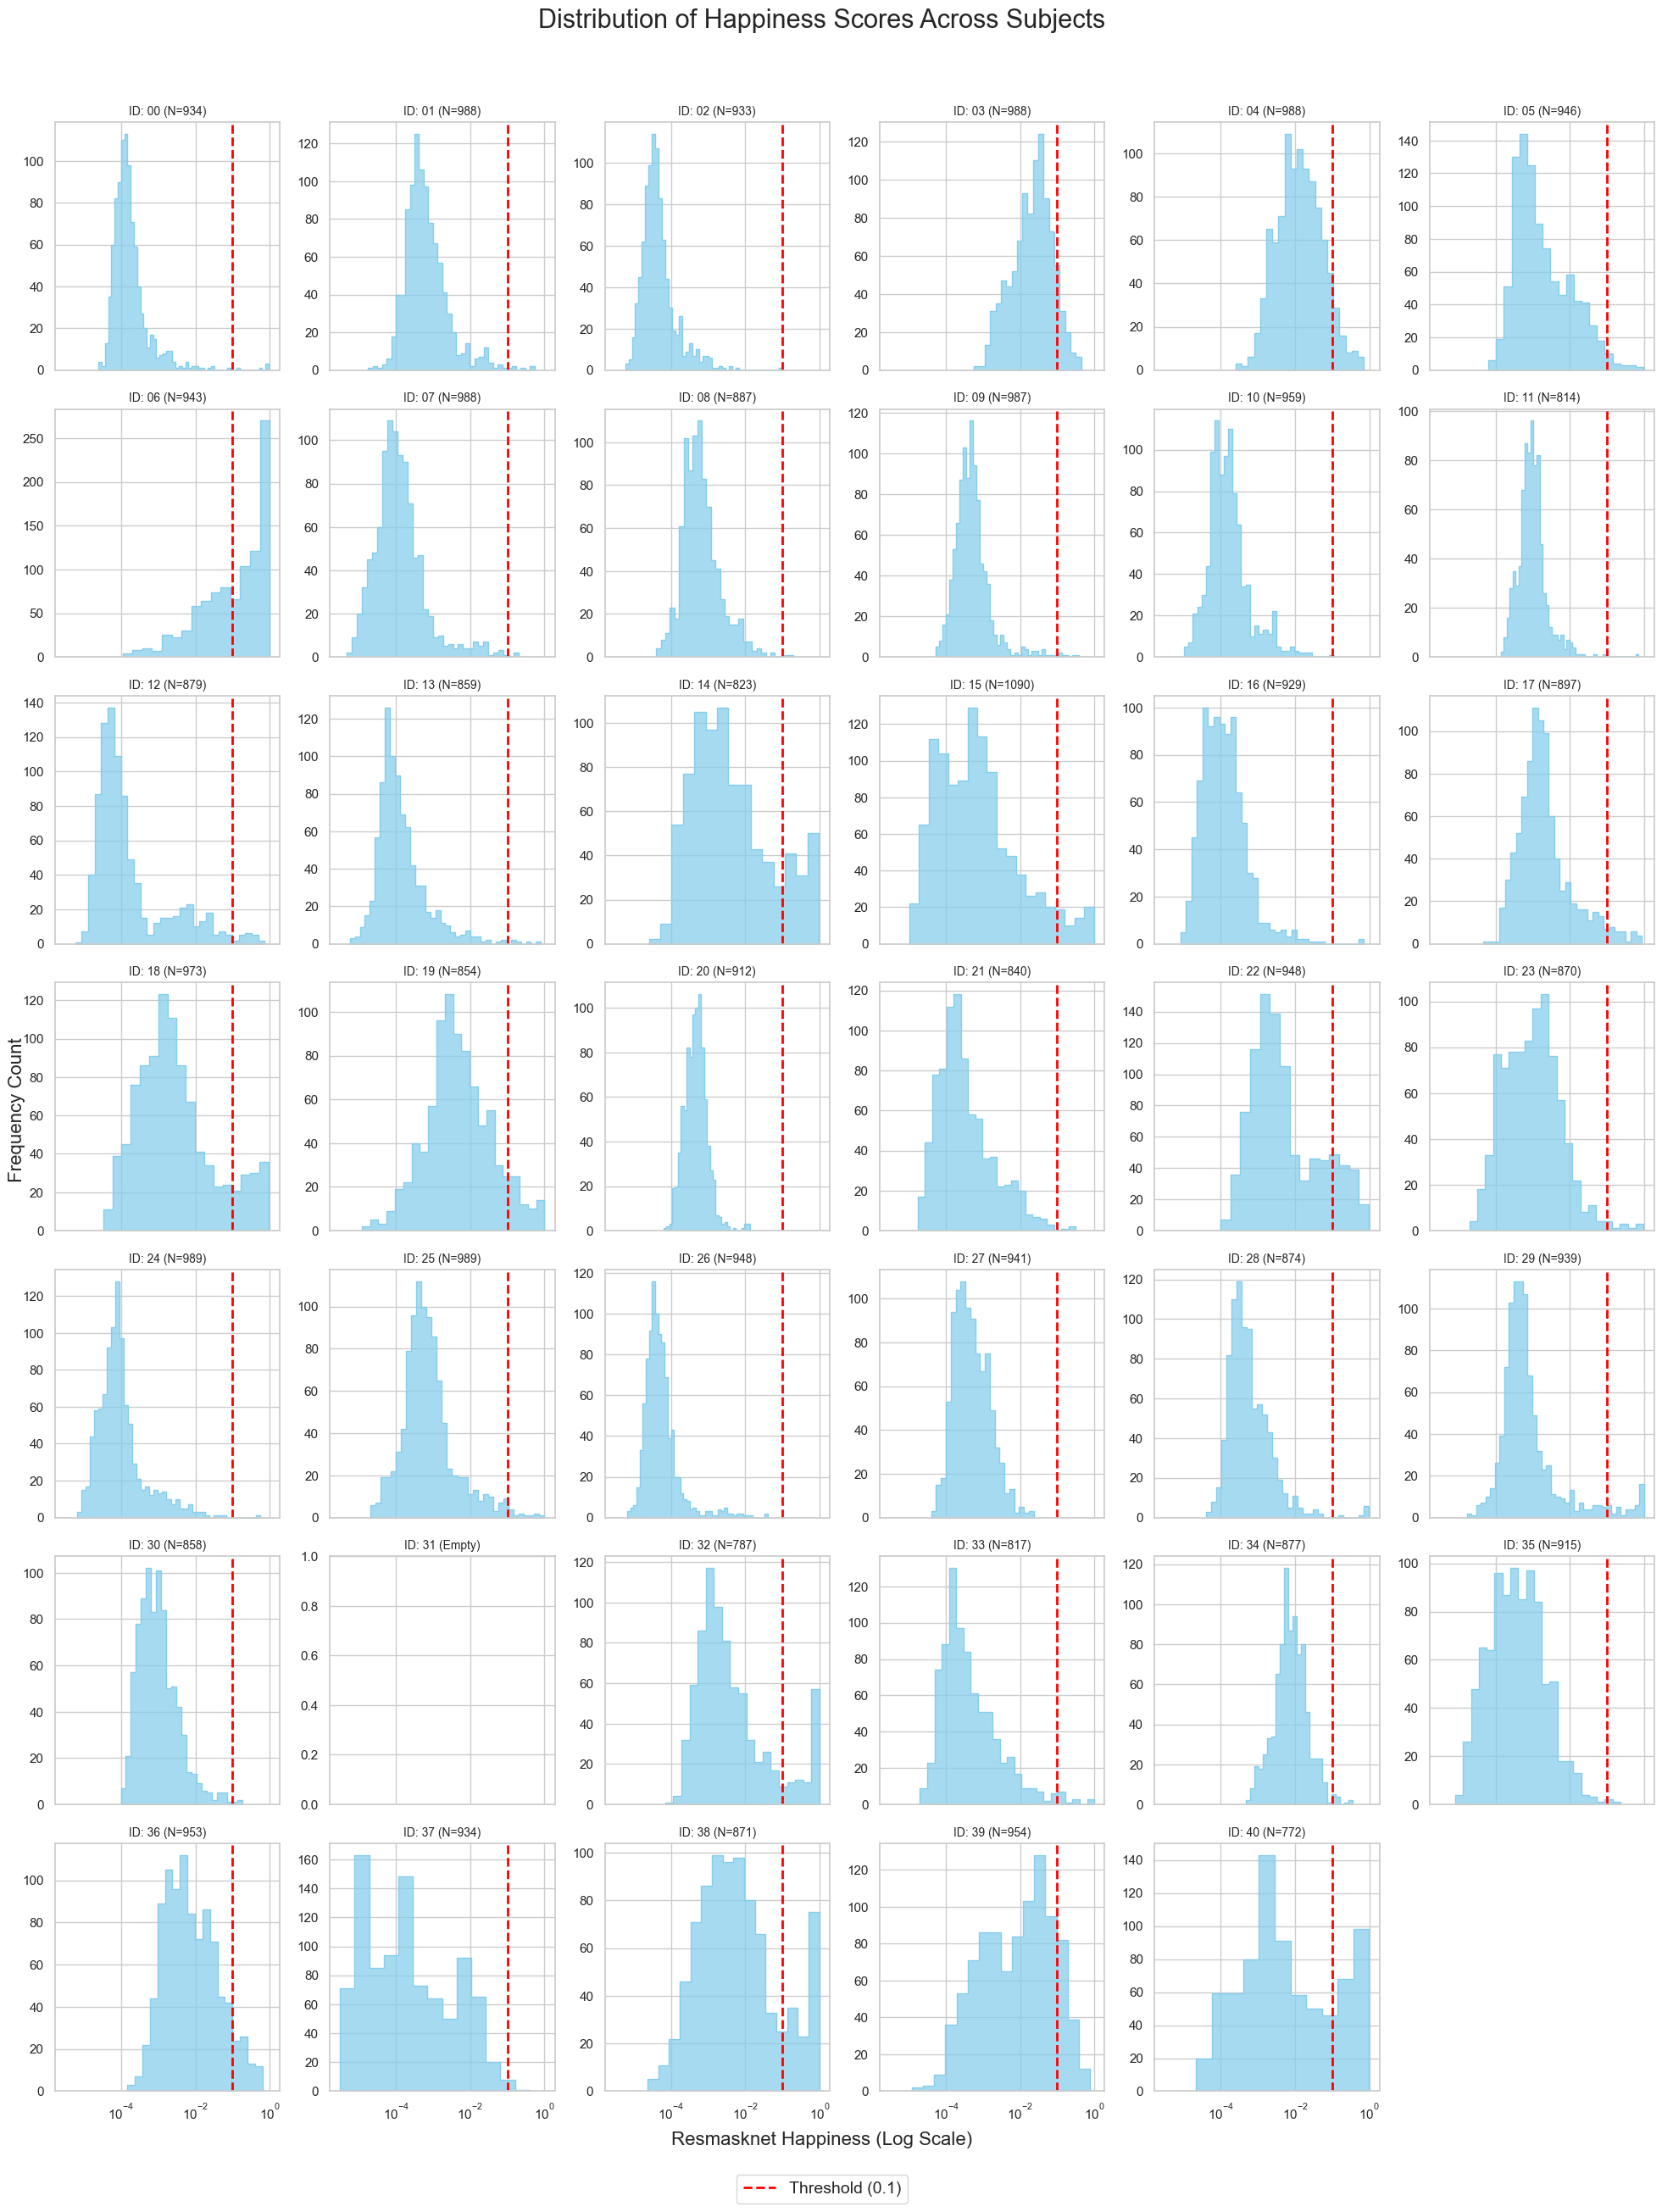

In [6]:
# Setup the grid
n_subjects = 41
cols = 6
rows = math.ceil(n_subjects / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, 25), sharex=True)
axes = axes.flatten()

for i in range(n_subjects):
    suffix = f"{i:02d}"
    subject_id = f"IFE-EC-NPFC-T003-{suffix}"
    ax = axes[i]
    
    df_sub = df[df['Subject_ID'] == subject_id]
    
    if not df_sub.empty:
        data = df_sub['resmasknet_happiness'].dropna()
        if not data.empty:
            sns.histplot(data=data, log_scale=True, color='skyblue', ax=ax, element="step")
            
            # Add the x=0.1 line. 
            # We add a label only once (for i==0) to keep the legend clean.
            line_label = "Threshold (0.1)" if i == 0 else "_"
            ax.axvline(0.1, color='red', linestyle='--', linewidth=2, label=line_label)
            
            ax.set_title(f"ID: {suffix} (N={len(df_sub)})", fontsize=10)
        else:
            ax.set_title(f"ID: {suffix} (Empty)", fontsize=10)
    else:
        ax.set_title(f"ID: {suffix} (Missing)", fontsize=10)
    
    ax.set_xlabel("")
    ax.set_ylabel("")

# Remove empty subplot
if len(axes) > n_subjects:
    fig.delaxes(axes[-1])

# --- Global Labels and Legend ---
fig.suptitle("Distribution of Happiness Scores Across Subjects", fontsize=22, y=1.02)
fig.supxlabel("Resmasknet Happiness (Log Scale)", fontsize=16)
fig.supylabel("Frequency Count", fontsize=16)

# Create a single legend for the entire figure at the bottom
fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=1, fontsize=14)

plt.tight_layout()
plt.savefig('../outputs/figures/phenomenon_3_fig3_happiness_distribution_per_subject.png', dpi=150, bbox_inches='tight')
plt.show()

In addition, if used the mean, the mean of happiness is very skewed towards 0.0. This approach also yields no significant correlation for happiness, although it is maintained for sadness.


### Correlation Results
| Metric | Correlation ($r$) | $p$-value |
| :--- | :--- | :--- |
| **Happiness** | -0.082 | 0.0640 |
| **Sadness** | -0.139 | 0.0015 |


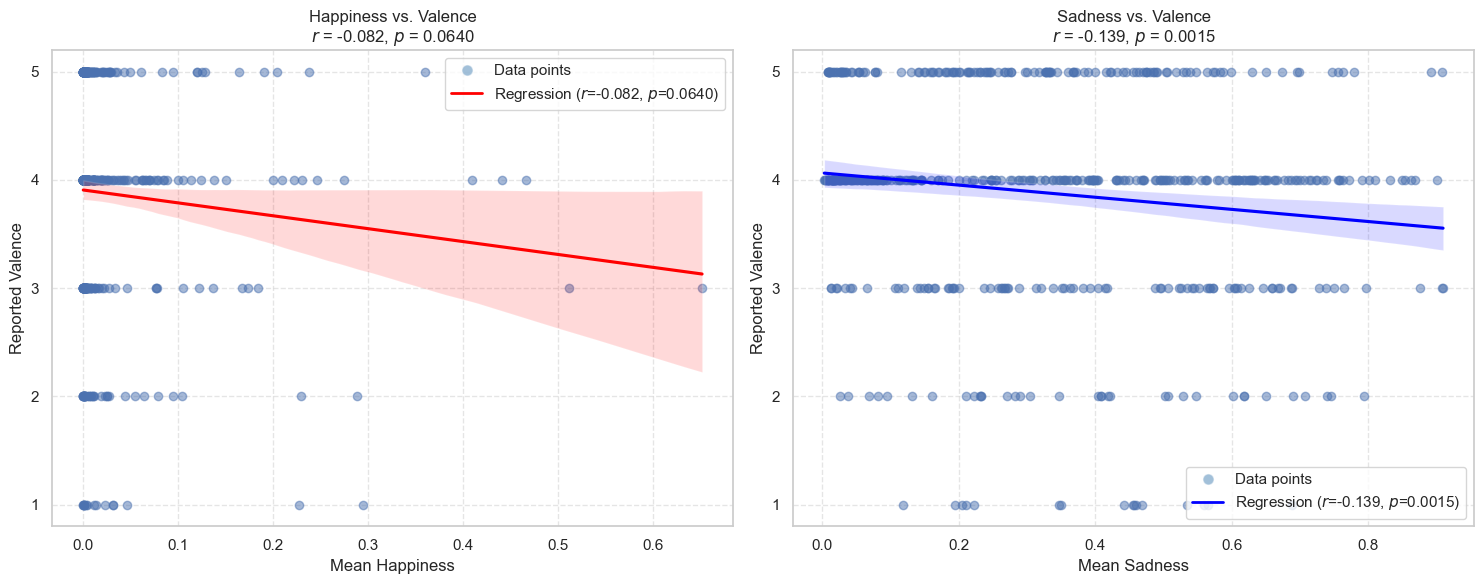

In [7]:
k_largest_df = df.groupby(['Subject_ID', 'Task_Num']).agg(
  agg_happiness=('resmasknet_happiness', 'mean'), 
  agg_sadness=('resmasknet_sadness', 'mean'), 
  reported_valence=('Selfreport_valence', 'max'), # Same for all
  reported_arousal=('Selfreport_arousal', 'max')
).reset_index()

k_largest_df = k_largest_df.dropna(subset=['reported_valence', 'agg_happiness', 'agg_sadness'])

corr_h, p_h = pearsonr(k_largest_df['reported_valence'], k_largest_df['agg_happiness'])
corr_s, p_s = pearsonr(k_largest_df['reported_valence'], k_largest_df['agg_sadness'])

display(Markdown(f"""
### Correlation Results
| Metric | Correlation ($r$) | $p$-value |
| :--- | :--- | :--- |
| **Happiness** | {corr_h:.3f} | {p_h:.4f} |
| **Sadness** | {corr_s:.3f} | {p_s:.4f} |
"""))

# Create a 1x2 grid (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Happiness vs Reported Valence
sns.regplot(
    ax=axes[0], 
    data=k_largest_df, 
    x='agg_happiness', 
    y='reported_valence', 
    scatter_kws={'alpha':0.5}, 
    line_kws={'color':'red'}
)
axes[0].set_title(f'Happiness vs. Valence\n$r$ = {corr_h:.3f}, $p$ = {p_h:.4f}')
axes[0].set_xlabel('Mean Happiness')
axes[0].set_ylabel('Reported Valence')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].set_yticks([1, 2, 3, 4, 5])
axes[0].legend(
    handles=[
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue',
                   alpha=0.5, markersize=8, label='Data points'),
        plt.Line2D([0], [0], color='red', linewidth=2,
                   label=f'Regression ($r$={corr_h:.3f}, $p$={p_h:.4f})')
    ]
)

# Plot 2: Sadness vs Reported Valence
sns.regplot(
    ax=axes[1], 
    data=k_largest_df, 
    x='agg_sadness', 
    y='reported_valence', 
    scatter_kws={'alpha':0.5}, 
    line_kws={'color':'blue'}
)
axes[1].set_title(f'Sadness vs. Valence\n$r$ = {corr_s:.3f}, $p$ = {p_s:.4f}')
axes[1].set_xlabel('Mean Sadness')
axes[1].set_ylabel('Reported Valence')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].set_yticks([1, 2, 3, 4, 5])
axes[1].legend(
    handles=[
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue',
                   alpha=0.5, markersize=8, label='Data points'),
        plt.Line2D([0], [0], color='blue', linewidth=2,
                   label=f'Regression ($r$={corr_s:.3f}, $p$={p_s:.4f})')
    ]
)

# Adjust layout to prevent label overlap
plt.tight_layout()
plt.savefig('../outputs/figures/phenomenon_3_fig4_deadend_mean_happiness_sadness.png', dpi=150, bbox_inches='tight')
plt.show()

# Discussion

## Key Findings

1. **Both facial expression signals correlate with valence, but in the opposite direction to what is expected.** In the pooled analysis, happiness showed *r* = −0.100 (*p* = 0.025) and sadness *r* = −0.151 (*p* = 0.001) against reported valence, statistically significant, yet negative in both cases. Higher peak happiness scores are associated with lower reported enjoyment, which directly contradicts the intuitive assumption.

2. **Per-task, significance is rare and concentrated in specific tasks.** For happiness, only tasks 3.1 (*r* = −0.395, *p* = 0.013) and 6.1 (*r* = −0.344, *p* = 0.032) reached significance out of 13 tasks. For sadness, only tasks 2.1 (*r* = −0.452, *p* = 0.004) and 8.1 (*r* = −0.420, *p* = 0.008) did. The remaining 11 tasks produced no significant result for either emotion.

3. **Participants display a neutral face for roughly half of each task, regardless of how much they enjoyed it.** Neutral expression percentages ranged from 38.5% (task 7.3) to 57.8% (task 4.1) across tasks, and the only significant per-task neutral correlation was task 3.1 (*r* = 0.377, *p* = 0.016, neutral avg. 40.7%), where higher enjoyment actually predicted *more* neutral frames, not fewer.

4. **There is a positive significant correlation between the enjoyment of a task and the percentage of time a person shows a neutral face.** This may be caused by concentration during the task or other factors. This correlation shows only when analyzing all the tasks together, not when separating the tasks.

---

## Theoretical Interpretation

1. **The negative correlations reflect the gap between felt and expressed emotions, not a model failure.** The background notes that internal emotional states do not map directly onto facial expressions [13], and participants who are aware of being recorded tend to suppress spontaneous expression [4]. A participant genuinely enjoying a task is experiencing high felt valence, but this does not produce the prototypical Ekman happiness expression that ResMaskNet was trained on [7][8].

2. **The valence–arousal model's limitations help explain the counterintuitive direction.** Research cited in the background shows that positive emotions can occur without the expressive prototype the model expects [15][16]. Tasks that produce enjoyment through cognitive engagement (e.g., concentration tasks) elicit a composed, neutral face rather than a visible smile — making the model's happiness signal inversely related to how much the person is actually enjoying themselves.

3. **The task 3.1 result aligns with Kreibig's (2010) finding that positive emotions produce weaker expressive responses than negative ones.** The math task showed the strongest neutral correlation (*r* = 0.377) at a below-average neutral rate (40.7%), and the strongest happiness correlation of any task (*r* = −0.395) — suggesting that cognitive demand shapes which emotional signal the model captures, and that the task type acts as a moderator of expression intensity.

---

## Implications for Methodological Design

1. **Task is an important variable that affects _how_ people show emotions.** Significance collapsed from 2 out of 2 pooled analyses to 2–4 out of 13 per-task analyses, making it clear that pooled results mask task-level heterogeneity. Accuracy and uncertainty metrics must always be reported at the task level to identify *which* situations the model performs well in.

2. **The neutral baseline (~40–58% of frames across all tasks) must be addressed before computing uncertainty metrics.** The model predicts neutral for roughly half of all frames. Uncertainty analysis should be computed separately for neutral-predicted and emotion-predicted frames to avoid inflated confidence on trivial predictions.

3. **Self-reported valence is not a valid ground truth for expressed emotion in this dataset.** The consistent negative correlations and low per-task significance rates confirm that felt valence and facial expression are measuring different constructs. The research design should directly address the key difference between felt and expressed emotions, understanding that valence does not indicate a happy or sad face expression.